In [ ]:
## Install required packages if not already available
!pip install roboflow pycocotools torchmetrics --quiet

In [ ]:
## Check the dataset location (e.g., in Kaggle it’s under /kaggle/working)
import os
print(os.listdir("/kaggle/working"))

In [ ]:
# ## Load JSON annotations and organize them into a DataFrame
# import os
# import json
# import pandas as pd

# # Define root directory (adjust based on your dataset)
# root = "/kaggle/working/Cup-Annotations-3"  # Replace with your project folder name
# partitions = ['train', 'test', 'valid']
# dataframes = []

# for partition in partitions:
#     annotation_path = f'{root}/{partition}/_annotations.coco.json'
#     if not os.path.exists(annotation_path):
#         print(f"⚠️ Skipping missing: {annotation_path}")
#         continue
    
#     with open(annotation_path, 'r') as f:
#         coco_data = json.load(f)
    
#     # Map image_id to file info
#     image_id_to_info = {img["id"]: img for img in coco_data["images"]}
    
#     # Extract annotations
#     rows = []
#     for ann in coco_data["annotations"]:
#         image_info = image_id_to_info[ann["image_id"]]
#         row = {
#             "image_id": ann["image_id"],
#             "file_name": image_info["file_name"],
#             "bbox": ann["bbox"],
#             "category_id": ann["category_id"],
#             "partition": partition
#         }
#         rows.append(row)
    
#     df = pd.DataFrame(rows)
#     dataframes.append(df)

# # Combine all partitions into one DataFrame
# full_df = pd.concat(dataframes, ignore_index=True)
# full_df[['x', 'y', 'width', 'height']] = pd.DataFrame(full_df['bbox'].tolist(), index=full_df.index)
# full_df = full_df.drop(columns=['bbox'])
# full_df = full_df[['image_id', 'file_name', 'x', 'y', 'width', 'height', 'category_id', 'partition']]

# print(full_df.groupby('partition').size())
# full_df.head(5)

In [ ]:
## Define a visualization function for bounding boxes
import cv2
import matplotlib.pyplot as plt

def visualize(image_path, bboxes, labels=None, box_color=(0, 255, 0), text_color=(255, 255, 255), thickness=2):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    for i, (x, y, w, h) in enumerate(bboxes):
        cv2.rectangle(image, (int(x), int(y)), (int(x+w), int(y+h)), box_color, thickness)
        if labels:
            label = labels[i]
            cv2.putText(image, label, (int(x), int(y)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, text_color, 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [ ]:
# ## Visualize random samples from each partition
# import random

# def visualize_random_from_partition(df, partition, image_base_path=root):
#     partition_df = df[df['partition'] == partition]
#     if partition_df.empty:
#         print(f"No data for partition: {partition}")
#         return
    
#     random_image_id = random.choice(partition_df['image_id'].unique())
#     rows = partition_df[partition_df['image_id'] == random_image_id]
    
#     image_path = os.path.join(image_base_path, partition, rows.iloc[0]['file_name'])
#     bboxes = rows[['x', 'y', 'width', 'height']].values.tolist()
#     labels = [f"Class {cid}" for cid in rows['category_id']]
    
#     print(f"Showing {partition} image: {rows.iloc[0]['file_name']}")
#     visualize(image_path, bboxes, labels)

# visualize_random_from_partition(full_df, "train")
# visualize_random_from_partition(full_df, "test")
# visualize_random_from_partition(full_df, "valid")

In [1]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from pycocotools.coco import COCO
import numpy as np
import albumentations as A
import os

class CocoDataset(Dataset):
    def __init__(self, root, annotation, transforms=None, occlusion_type='significant', occlusion_threshold=0.4):
        """
        Args:
            root: directory of images
            annotation: path to COCO JSON
            transforms: Albumentations pipeline
            occlusion_type: 'any', 'degree', 'significant'
            occlusion_threshold: IoU threshold for 'degree', occlusion ratio for 'significant'
        """
        self.root       = root
        self.coco       = COCO(annotation)
        self.transforms = transforms
        self.occlusion_type = occlusion_type
        self.occlusion_threshold = occlusion_threshold

        # 1) Identify vehicle category IDs
        all_cats = self.coco.loadCats(self.coco.getCatIds())
        self.vehicle_cat_ids = {c['id'] for c in all_cats if c['supercategory']=="vehicle"}

        # 2) Build mapping from those vehicle IDs → contiguous 1..N
        cats_sorted = sorted(self.vehicle_cat_ids)
        self.id_to_label = {cid: idx+1 for idx, cid in enumerate(cats_sorted)}
        # 0 will be background (unused since we drop non-vehicle)

        # 3) PRE-FILTER image IDs based on occlusion criteria
        self.img_ids = self._filter_image_ids()

    def calculate_iou(self, b1, b2):
        x1, y1, w1, h1 = b1
        x2, y2, w2, h2 = b2
        xi1, yi1 = max(x1, x2), max(y1, y2)
        xi2, yi2 = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
        inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
        box1_area = w1 * h1
        box2_area = w2 * h2
        union_area = box1_area + box2_area - inter_area
        return inter_area / union_area if union_area > 0 else 0

    def _check_any_occlusion(self, vehicle_boxes, other_boxes, iou_thresh):
        return any(
            self.calculate_iou(vb, ob) > iou_thresh
            for vb in vehicle_boxes
            for ob in other_boxes
        )

    def _check_degree_occlusion(self, vehicle_boxes, other_boxes, degree_threshold):
        return any(
            self.calculate_iou(vb, ob) > degree_threshold
            for vb in vehicle_boxes
            for ob in other_boxes
        )

    def _check_significant_occlusion(self, vehicle_anns, other_anns, ratio_threshold):
        for v_ann in vehicle_anns:
            v_bbox = v_ann['bbox']
            v_area = v_bbox[2] * v_bbox[3]
            for o_ann in other_anns:
                o_bbox = o_ann['bbox']
                intersection_x1 = max(v_bbox[0], o_bbox[0])
                intersection_y1 = max(v_bbox[1], o_bbox[1])
                intersection_x2 = min(v_bbox[0] + v_bbox[2], o_bbox[0] + o_bbox[2])
                intersection_y2 = min(v_bbox[1] + v_bbox[3], o_bbox[1] + o_bbox[3])
                intersection_area = max(0, intersection_x2 - intersection_x1) * max(0, intersection_y2 - intersection_y1)
                if v_area > 0 and (intersection_area / v_area) > ratio_threshold:
                    return True
        return False

    def _filter_image_ids(self):
        filtered_ids = []
        for img_id in sorted(self.coco.imgs.keys()):
            ann_ids = self.coco.getAnnIds(imgIds=img_id)
            anns = self.coco.loadAnns(ann_ids)

            vehicle_anns = [a for a in anns if a['category_id'] in self.vehicle_cat_ids]
            other_anns = [a for a in anns if a['category_id'] not in self.vehicle_cat_ids]
            vehicle_boxes = [a['bbox'] for a in vehicle_anns]
            other_boxes = [a['bbox'] for a in other_anns]

            if not vehicle_boxes:
                continue

            occluded = False
            if self.occlusion_type == 'any':
                occluded = self._check_any_occlusion(vehicle_boxes, other_boxes, self.occlusion_threshold)
            elif self.occlusion_type == 'degree':
                occluded = self._check_degree_occlusion(vehicle_boxes, other_boxes, self.occlusion_threshold)
            elif self.occlusion_type == 'significant':
                occluded = self._check_significant_occlusion(vehicle_anns, other_anns, self.occlusion_threshold)
            else:
                raise ValueError(f"Invalid occlusion_type: {self.occlusion_type}")

            if occluded:
                filtered_ids.append(img_id)
        return filtered_ids

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, index):
        coco    = self.coco
        img_id = self.img_ids[index]

        # load image
        info    = coco.loadImgs(img_id)[0]
        img     = np.array(Image.open(os.path.join(self.root, info['file_name'])).convert("RGB"))

        # load only vehicle annotations
        ann_ids = coco.getAnnIds(imgIds=img_id, catIds=list(self.vehicle_cat_ids))
        anns    = coco.loadAnns(ann_ids)

        boxes   = []
        labels  = []
        for ann in anns:
            x,y,w,h = ann['bbox']
            boxes.append([x, y, x+w, y+h])
            labels.append(self.id_to_label[ann['category_id']])

        boxes   = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }

        # apply transforms
        if self.transforms:
            transformed = self.transforms(image=img)
            img = transformed["image"]

        return img, target

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.6' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
from torch.utils.data import DataLoader
from torchvision import transforms
from albumentations.pytorch import ToTensorV2
import albumentations as A
import matplotlib.pyplot as plt
import numpy as np

def get_transform(train=True):
    transforms_list = [
        A.Resize(256, 256),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ]
    if train:
        additional_transforms = [
            A.RandomBrightnessContrast(p=0.1),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=5, p=0.1),
            A.GaussianBlur(blur_limit=2, p=0.1),
        ]
        transforms_list = additional_transforms + transforms_list
    return A.Compose(transforms_list)


def collate_fn(batch):
    return tuple(zip(*batch))

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_dataset_info(train_dataset, val_dataset, train_loader, val_loader, num_samples=4):
    """
    Visualizes sample images from the training dataset and prints dataset information.

    Args:
        train_dataset: The training Dataset object.
        val_dataset: The validation Dataset object.
        train_loader: The training DataLoader object.
        val_loader: The validation DataLoader object.
        num_samples: The number of sample images to visualize from the training set.
    """

    print("Visualizing transformations on training data:")
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 5))
    for i in range(num_samples):
        try:
            image, _ = train_dataset[i]
            # Transpose the image tensor for proper display (C, H, W) -> (H, W, C)
            img_np = image.permute(1, 2, 0).cpu().numpy()
            # Unnormalize for visualization
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_np = std * img_np + mean
            img_np = np.clip(img_np, 0, 1)
            axes[i].imshow(img_np)
            axes[i].axis('off')
            axes[i].set_title(f"Sample {i+1}")
        except IndexError:
            print(f"Warning: Could not retrieve sample {i+1} from training dataset.")
            break
    plt.tight_layout()
    plt.show()

    print("\nDataLoaders created.")
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    print(f"Train dataloader length: {len(train_loader)}")
    print(f"Validation dataloader length: {len(val_loader)}")

## Occlusion with IOU threshold

loading annotations into memory...
Done (t=19.16s)
creating index...
index created!
loading annotations into memory...
Done (t=0.64s)
creating index...
index created!
Visualizing transformations on training data:


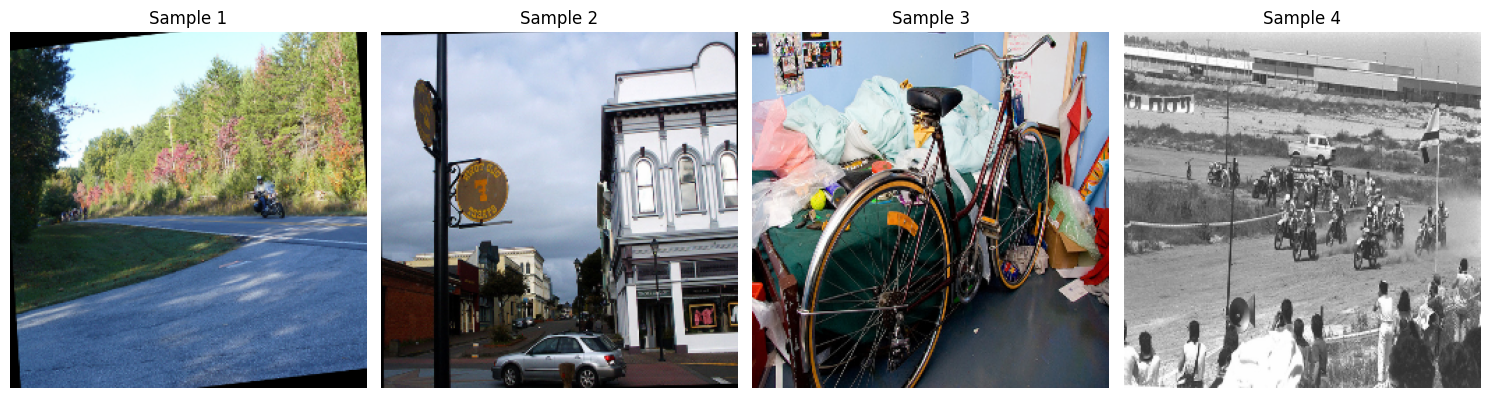


DataLoaders created.
Train dataset size: 1702
Validation dataset size: 61
Train dataloader length: 426
Validation dataloader length: 16
ID to Label Mapping: {2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8}


In [4]:
train_dataset_run1 = CocoDataset(
    root='/kaggle/input/2017-2017/train2017/train2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_train2017.json',
    transforms=get_transform(train=True),
    occlusion_type='any',
    occlusion_threshold=0.4  
)
val_dataset_run1 = CocoDataset(
    root='/kaggle/input/2017-2017/val2017/val2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_val2017.json',
    transforms=get_transform(train=False),
    occlusion_type='any',
    occlusion_threshold=0.4
)
train_loader_run1 = DataLoader(train_dataset_run1, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_loader_run1 = DataLoader(val_dataset_run1, batch_size=4, shuffle=False, collate_fn=collate_fn)

# Visualize
visualize_dataset_info(train_dataset_run1, val_dataset_run1, train_loader_run1, valid_loader_run1)
print("ID to Label Mapping:", train_dataset_run1.id_to_label)

## Significant Occlusion Threshold 

In [ ]:
train_dataset_run2 = CocoDataset(
    root='/kaggle/input/2017-2017/train2017/train2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_train2017.json',
    transforms=get_transform(train=True),
    occlusion_type='significant',
    occlusion_threshold=0.3  # Example: 50% occlusion
)
val_dataset_run2 = CocoDataset(
    root='/kaggle/input/2017-2017/val2017/val2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_val2017.json',
    transforms=get_transform(train=False),
    occlusion_type='significant',
    occlusion_threshold=0.5
)
train_loader_run2 = DataLoader(train_dataset_run2, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_loader_run2 = DataLoader(val_dataset_run2, batch_size=4, shuffle=False, collate_fn=collate_fn)

# For Run 2
visualize_dataset_info(train_dataset_run2, val_dataset_run2, train_loader_run2, valid_loader_run2)

## Degree of Occlusion

In [ ]:
train_dataset_run3 = CocoDataset(
    root='/kaggle/input/2017-2017/train2017/train2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_train2017.json',
    transforms=get_transform(train=True),
    occlusion_type='degree',
    occlusion_threshold=0.5  # Example: IoU > 0.5
)
val_dataset_run3 = CocoDataset(
    root='/kaggle/input/2017-2017/val2017/val2017',
    annotation='/kaggle/input/2017-2017/annotations_trainval2017/annotations/instances_val2017.json',
    transforms=get_transform(train=False),
    occlusion_type='degree',
    occlusion_threshold=0.5
)
train_loader_run3 = DataLoader(train_dataset_run3, batch_size=4, shuffle=True, collate_fn=collate_fn)
valid_loader_run3 = DataLoader(val_dataset_run3, batch_size=4, shuffle=False, collate_fn=collate_fn)


# For Run 3
visualize_dataset_info(train_dataset_run3, val_dataset_run3, train_loader_run3, valid_loader_run3)

In [5]:
## Define RetinaNet model
import torch
import torchvision
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from torchinfo import summary


class RetinaNetModel(torch.nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        self.model = retinanet_resnet50_fpn(pretrained=pretrained)
        in_features = 256  # Default FPN output channels
        num_anchors = self.model.head.classification_head.num_anchors
        self.model.head.classification_head = RetinaNetClassificationHead(
            in_channels=in_features,
            num_anchors=num_anchors,
            num_classes=num_classes
        )
    
    def forward(self, images, targets=None):
        if self.training:
            return self.model(images, targets)
        else:
            return self.model(images)

# Number of classes = background + your object class (e.g., cup)
num_vehicle_classes = len(train_dataset_run1.id_to_label)
num_classes = num_vehicle_classes + 1
print(f"Number of vehicle classes: {num_vehicle_classes}")
print(f"Total number of classes (including background): {num_classes}")
model = RetinaNetModel(num_classes=num_classes)


input_size = (1, 3, 256, 256) 

# Get the model summary
model_summary = summary(model, input_size=input_size)

print(model_summary)

Number of vehicle classes: 8
Total number of classes (including background): 9


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=RetinaNet_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=RetinaNet_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth
100%|██████████| 130M/130M [00:00<00:00, 202MB/s]  


Layer (type:depth-idx)                                       Output Shape              Param #
RetinaNetModel                                               [0, 4]                    --
├─RetinaNet: 1-1                                             [0, 4]                    --
│    └─GeneralizedRCNNTransform: 2-1                         [1, 3, 800, 800]          --
│    └─BackboneWithFPN: 2-2                                  [1, 256, 7, 7]            --
│    │    └─IntermediateLayerGetter: 3-1                     [1, 2048, 25, 25]         23,454,912
│    │    └─FeaturePyramidNetwork: 3-2                       [1, 256, 7, 7]            3,868,672
│    └─RetinaNetHead: 2-3                                    [1, 120087, 4]            --
│    │    └─RetinaNetClassificationHead: 3-3                 [1, 120087, 9]            2,547,025
│    │    └─RetinaNetRegressionHead: 3-4                     [1, 120087, 4]            2,443,300
│    └─AnchorGenerator: 2-4                                  [1200

In [8]:
## Set up training parameters
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

num_epochs = 50  # Increased number of epochs
learning_rate = 1e-4

params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params, lr=learning_rate)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.2) 

In [9]:
## Define training and validation functions
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, device, epoch):
    model.train()
    total_loss = 0
    
    pbar = tqdm(dataloader, desc=f"[Epoch {epoch}] Training")
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        loss = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix(loss=loss.item())
    
    avg_loss = total_loss / len(dataloader)
    print(f"✅ Finished Epoch {epoch} | Avg Loss: {avg_loss:.4f}")

def validate(model, dataloader, device, epoch):
    model.eval()
    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc=f"[Epoch {epoch}] Validating"):
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            outputs = model(images)  # Basic validation, extend with metrics as needed

In [ ]:
import torch
import torch.optim as optim
import torchvision.models as models
import tensorflow as tf

# Define device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


for epoch in range(1, num_epochs + 1):
    train_one_epoch(model, train_loader_run1, optimizer, device, epoch)
    validate(model, valid_loader_run1, device, epoch)

# Save the trained PyTorch model weights
torch.save(model.state_dict(), "retinanet_detector_run1.pth")
print("Training complete! Model saved.")

2025-05-05 00:29:45.954095: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746404986.147663      55 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746404986.198652      55 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
[Epoch 1] Training: 100%|██████████| 426/426 [02:58<00:00,  2.39it/s, loss=3.9] 


✅ Finished Epoch 1 | Avg Loss: 12.1985


[Epoch 2] Training: 100%|██████████| 426/426 [02:45<00:00,  2.57it/s, loss=2.52]


✅ Finished Epoch 2 | Avg Loss: 11.3632


[Epoch 3] Training: 100%|██████████| 426/426 [02:45<00:00,  2.57it/s, loss=6.13]


...

[Epoch 24] Training: 100%|██████████| 426/426 [02:45<00:00,  2.57it/s, loss=12.1]


✅ Finished Epoch 24 | Avg Loss: 9.4786


[Epoch 25] Training: 100%|██████████| 426/426 [02:45<00:00,  2.57it/s, loss=14.5]


✅ Finished Epoch 25 | Avg Loss: 9.4212


[Epoch 26] Training:  81%|████████  | 343/426 [02:14<00:32,  2.56it/s, loss=12.9]

In [ ]:
# Load your trained PyTorch model
num_classes = len(train_dataset_run1.id_to_label) + 1
loaded_model = RetinaNetModel(num_classes=num_classes)
loaded_model.load_state_dict(torch.load("retinanet_detector_run1.pth"))
loaded_model.eval() # Set to evaluation mode

# Define a dummy input (match the size your model expects)
dummy_input = torch.randn(1, 3, 256, 256)
dummy_input = dummy_input.to(device)
loaded_model.to(device)

# Export to ONNX
torch.onnx.export(loaded_model,
                  dummy_input,
                  "retinanet.onnx",
                  export_params=True,
                  opset_version=11, # Or a suitable version
                  do_constant_folding=True,
                  input_names=['input'],
                  output_names=['output'])

print("PyTorch model exported to ONNX: retinanet.onnx")

In [ ]:

# Convert the ONNX model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_onnx_file("retinanet.onnx")
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# If you want to apply quantization (important for mobile performance):
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

# Provide a representative dataset for post-training quantization
def representative_dataset():
    for _ in range(100): # Example: use 100 samples
        image, _ = train_dataset[np.random.randint(len(train_dataset))]
        yield [image.unsqueeze(0).numpy().astype(np.float32)]
converter.representative_dataset = representative_dataset

tflite_model = converter.convert()

# Save the TensorFlow Lite model
with open("retinanet.tflite", "wb") as f:
    f.write(tflite_model)

print("ONNX model converted to TensorFlow Lite: retinanet.tflite")

# Create the label map file
with open("retinanet_labels.txt", "w") as f:
    for label in sorted(train_dataset.id_to_label.values()):
        f.write(f"{label}\n")
print("Label map saved to retinanet_labels.txt")

In [ ]:
## Evaluate model and print metrics table
import torch
from torchvision.ops import box_iou
import time
import pandas as pd
import torchmetrics

def evaluate_model(model, dataloader, device):
    model.eval()
    results = {"mAP@50": 0.0, "mAP@50-95": 0.0, "Precision": 0.0, "Recall": 0.0, "FPS": 0.0, "IoU": 0.0}
    
    # Initialize torchmetrics for mAP
    metric = torchmetrics.detection.MeanAveragePrecision(iou_thresholds=[0.4, 0.75, 0.95])
    all_preds = []  # Fixed: Initialize as separate empty lists
    all_targets = []  # Fixed: Initialize as separate empty lists
    total_time = 0
    num_images = 0
    total_iou = 0
    num_iou_comparisons = 0
    
    with torch.no_grad():
        for images, targets in dataloader:
            images = [img.to(device) for img in images]
            start_time = time.time()
            outputs = model(images)
            total_time += time.time() - start_time
            
            for output, target in zip(outputs, targets):
                pred_boxes = output["boxes"].cpu()
                pred_scores = output["scores"].cpu()
                pred_labels = output["labels"].cpu()
                gt_boxes = target["boxes"].cpu()
                gt_labels = target["labels"].cpu()
                
                # Ensure predictions and targets are valid
                if pred_boxes.numel() == 0 or gt_boxes.numel() == 0:
                    continue
                
                pred = {
                    "boxes": pred_boxes,
                    "scores": pred_scores,
                    "labels": pred_labels,
                }
                gt = {
                    "boxes": gt_boxes,
                    "labels": gt_labels,
                }
                all_preds.append(pred)
                all_targets.append(gt)
                
                # IoU calculation
                if pred_boxes.numel() > 0 and gt_boxes.numel() > 0:
                    iou_matrix = box_iou(pred_boxes, gt_boxes)
                    max_iou_per_pred = iou_matrix.max(dim=1).values
                    total_iou += max_iou_per_pred.sum().item()
                    num_iou_comparisons += len(max_iou_per_pred)
            
            num_images += len(images)
    
    # Compute metrics only if there are predictions
    if all_preds and all_targets:
        metric.update(all_preds, all_targets)
        metric_summary = metric.compute()
        results["mAP@50"] = float(metric_summary["map_50"]) if metric_summary["map_50"] is not None else 0.0
        results["mAP@50-95"] = float(metric_summary["map"]) if metric_summary["map"] is not None else 0.0
        results["Precision"] = float(metric_summary["map"]) if metric_summary["map"] is not None else 0.0  # Proxy
        results["Recall"] = float(metric_summary["mar_100"]) if metric_summary["mar_100"] is not None else 0.0
    results["Inference Time"] = num_images / total_time if total_time > 0 else 0.0
    results["IoU"] = total_iou / num_iou_comparisons if num_iou_comparisons > 0 else 0.0
    
    return results

# Evaluate on test set
results = evaluate_model(model, valid_loader_run1, device)

# Build a DataFrame of final metrics
df = pd.DataFrame([{
    "mAP@50":     results["mAP@50"],
    "mAP@50-95":  results["mAP@50-95"],
    "Precision":  results["Precision"],
    "Recall":     results["Recall"],
    "Inference Time":        results["Inference Time"],
    "IoU":        results["IoU"]
}])

print("\nMetrics Table:")
print(df)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms.functional as F
import cv2
import os
from tqdm import tqdm  # Import tqdm for progress bar

def visualize_detections(model, dataloader, device, save_dir="detections", num_images=5, score_threshold=0.5, display=True):
    model.eval()
    os.makedirs(save_dir, exist_ok=True) # Create the save directory if it doesn't exist

    # Normalization used for training
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    n = num_images
    print("Total batches in dataloader:", len(dataloader))
    print(f"Visualizing detections on up to {n} images.")

    detection_images = []
    processed_count = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, total=min(len(dataloader), (num_images + dataloader.batch_size - 1) // dataloader.batch_size)):
            images, targets = batch
            for i in range(len(images)):
                if processed_count >= num_images:
                    break

                img = images[i]
                orig_img = img.cpu().numpy()
                if orig_img.shape[0] == 3:
                    orig_img = np.transpose(orig_img, (1, 2, 0))  # Convert from (C, H, W) to (H, W, C)

                # Denormalize the image
                orig_img = (orig_img * std) + mean
                orig_img = np.clip(orig_img, 0, 1)
                img_disp = (orig_img * 255).astype(np.uint8).copy()

                # Move image tensor to device and get model predictions
                image_tensor = img.to(device).unsqueeze(0) # Add batch dimension
                output = model(image_tensor)[0]

                # Extract detection results
                boxes = output["boxes"].cpu().numpy()
                scores = output["scores"].cpu().numpy()
                labels = output["labels"].cpu().numpy()

                # Filter out low-confidence detections
                keep = scores >= score_threshold
                boxes, scores, labels = boxes[keep], scores[keep], labels[keep]

                # Draw bounding boxes
                for box, score, label in zip(boxes, scores, labels):
                    x_min, y_min, x_max, y_max = box.astype(int)
                    cv2.rectangle(img_disp, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                    text = f"{label}: {score:.2f}"
                    cv2.putText(img_disp, text, (x_min, y_min - 10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

                # Convert BGR->RGB for saving and display
                img_disp_rgb = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB)
                detection_images.append(img_disp_rgb)

                # Save the image
                save_path = os.path.join(save_dir, f"detection_{processed_count+1}.jpg")
                cv2.imwrite(save_path, cv2.cvtColor(img_disp, cv2.COLOR_RGB2BGR))  # Convert RGB back to BGR for OpenCV
                print(f"Saved: {save_path}")
                processed_count += 1

            if processed_count >= num_images:
                break

    if display and detection_images:
        num_rows = (len(detection_images) + 2) // 3  # Arrange in roughly 3 columns
        num_cols = min(len(detection_images), 3)
        fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
        axes = axes.flatten() # Flatten the axes array for easy indexing

        for i, img in enumerate(detection_images):
            if i < len(axes):
                axes[i].imshow(img)
                axes[i].axis('off')
                axes[i].set_title(f"Detection {i+1}")

        # Hide any unused subplots
        for j in range(len(detection_images), len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

    print(f"\nProcessed and saved {len(detection_images)} images to '{save_dir}'")

# Visualize predictions on test set
visualize_detections(model, valid_loader_run1, device, num_images=5, score_threshold=0.2, display=True)

PART2: Image segementation

Mask R-CNN

Segformer model

U-Net model